In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#membacan data
file_path = 'data/customer_segmentation_dataset.csv'

data = pd.read_csv(file_path)
data

,customer_id,umur,penghasilan_juta,spending_score,segment_label
0,0668fc97-97cf-4d31-8cee-5f6aa3ead634,38,13.43,7.83,high
1,2a04cd5f-b0f4-4770-96d6-0cd1d97ce40a,20,3.71,3.71,low
2,c8b7ed92-61bc-457d-88c5-9f70d78498fc,37,23.04,7.10,high
3,97cd4f83-07d0-4f29-9dab-7a170de45fb8,21,2.20,3.41,low
4,34139432-4ba0-4eae-8e56-dab108e6881b,41,25.17,9.10,high
...,...,...,...,...,...
995,cc33739e-40ea-485a-b962-81fecb0e234e,40,18.33,7.17,high
996,e314940a-fd0f-4e5a-9997-2b7fb4034cb6,33,6.47,7.09,middle
997,f65845a7-72c5-413c-a1dd-75330070306f,59,15.69,9.36,high
998,b1934f5f-6f3e-4074-b129-c931640b3998,20,3.34,3.53,low


In [3]:
data.describe()

,umur,penghasilan_juta,spending_score
count,1000.000000,1000.000000,1000.000000
mean,36.296000,11.030930,5.872650
std,12.926774,8.256995,2.461571
min,18.000000,1.500000,1.020000
25%,26.000000,3.910000,4.080000
50%,35.000000,8.510000,5.975000
75%,44.000000,17.517500,7.840000
max,65.000000,29.910000,9.990000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1000 non-null   str    
 1   umur              1000 non-null   int64  
 2   penghasilan_juta  1000 non-null   float64
 3   spending_score    1000 non-null   float64
 4   segment_label     1000 non-null   str    
dtypes: float64(2), int64(1), str(2)
memory usage: 39.2 KB


In [5]:
#mengambil data untuk dicluster dan diubah ke numpy
# datas_points = data[["umur", "penghasilan_juta"]].values
datas_points = data[["umur", "penghasilan_juta"]].to_numpy()
# print(datas_points)
# print(type(datas_points))

In [6]:
#centroid atau titik
centroids = np.array([
    [20, 3.71], 
    [37, 23.04],
    [41, 25.17]
])

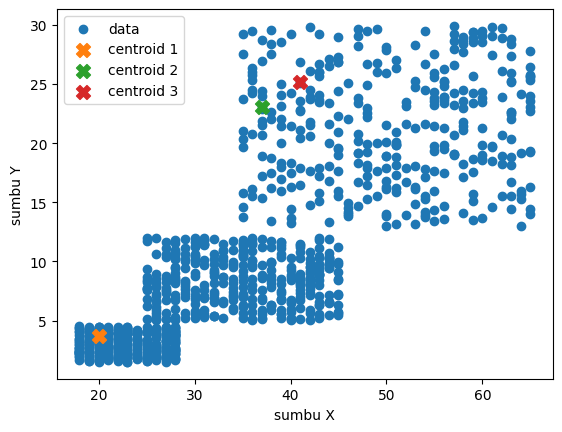

In [7]:
# ploting data point dan centroid sebelum 
x_points = datas_points[:, 0]
y_points = datas_points[:, 1]
#centroid
    
plt.scatter(x_points, y_points, label="data")
for ctd in range(len(centroids)):
    stp = centroids[ctd]
    plt.scatter(stp[0], stp[1], label=f"centroid {ctd + 1}", marker="X", s=100)

#label
plt.xlabel("sumbu X")
plt.ylabel("sumbu Y")
#menampilkan plot
plt.legend()
plt.show()

In [19]:
# membuat algoritma k-means
# fungsi untuk menghitung jarak
def distance(p, c):
    return ((p[0] - c[0])**2 + (p[1] - c[1])**2) **0.5 

#menghitung new centroid
def new_centroids(Centroid):
    if(len(Centroid) == 0):
        return np.array([0, 0])
    else:
        data_centroids = Centroid.copy()
        #ubah ke np.array([])
        data_centroids = np.array(data_centroids)
        #hitung rata rata
        values_0 = np.mean(data_centroids[:, 0])
        values_1 = np.mean(data_centroids[:, 1])

        return values_0, values_1

        

# fungsi untuk mencari cluster
def k_means(datas, centroid):
    # data dan centroid
    poitns = datas.copy()
    old_c = centroid.copy()

    # riwayat centroid
    history_centroid = []
    history_centroid.append(old_c.copy())

    # memulai mencari distance atau jarak
    final_c = old_c.copy() # menyimpan final centroid
    status = True
    while(status):
        # membuat cluster dari panjang centroid
        K = len(old_c)
        klusters = []
        for k in range(K):
            klusters.append([])

        #cluster index
        index_cluster = []
        # hitung jarak ke setiap centroid
        for point in poitns:
            # simpan semua jarak
            all_distances = []

            for c in range(len(old_c)):
                titik = old_c[c]

                #hitung jarak
                distances = distance(point, titik)
                all_distances.append(distances)

            index_terdekat = np.argmin(all_distances)
            klusters[index_terdekat].append(point)
            index_cluster.append(index_terdekat)


        # mencari nilai centroid baru
        new_c = []
        for kluster in range(len(klusters)):
            Kluster = klusters[kluster]
            n_centroid = new_centroids(Kluster)
            new_c.append(n_centroid)

        new_c = np.array(new_c)

        if(np.allclose(new_c, old_c)):
            status = False
        else: 
            old_c = new_c.copy()

            # history centroid
            history_centroid.append(old_c.copy())

            # centroid final
            final_c = old_c.copy()
            
    return klusters, final_c, history_centroid, index_cluster

In [26]:
all_kluster, final_centroids, h_centroid, idx_cluster= k_means(datas_points, centroids)
data["cluster"] = idx_cluster
#label dataset
label_map = {
    0: "Low Income",
    1: "Middle Income",
    2: "High Income"
}

data["label"] =  data["cluster"].map(label_map)
data.head()
# for kls in range(len(all_kluster)):
#     print(f"kluster ke { kls + 1}: {all_kluster[kls]}")


# print(final_centroids)
# for f_centroid in range(len(final_centroids)):
#     print(f"centroid ke { f_centroid + 1}: {final_centroids[f_centroid]}")

# print(h_centroid)

,customer_id,umur,penghasilan_juta,spending_score,segment_label,cluster,label
0,0668fc97-97cf-4d31-8cee-5f6aa3ead634,38,13.43,7.83,high,1,Middle Income
1,2a04cd5f-b0f4-4770-96d6-0cd1d97ce40a,20,3.71,3.71,low,0,Low Income
2,c8b7ed92-61bc-457d-88c5-9f70d78498fc,37,23.04,7.10,high,1,Middle Income
3,97cd4f83-07d0-4f29-9dab-7a170de45fb8,21,2.20,3.41,low,0,Low Income
4,34139432-4ba0-4eae-8e56-dab108e6881b,41,25.17,9.10,high,1,Middle Income


In [27]:
#import data 
# data.to_csv("customer_segmented_label_cluster.csv", index=False)

In [30]:
# menyimpan final centroid
file_path_c = "data"
np.save(f"{file_path_c}/centroids.npy", final_centroids)

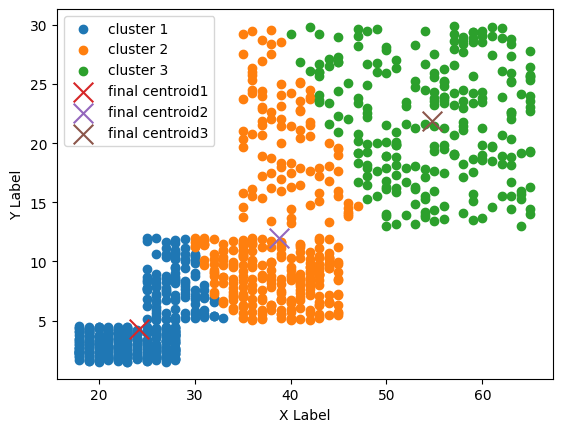

In [35]:
#ploting data setelah cluster
#data cluster
for kls in range(len(all_kluster)):
    cluster = np.array(all_kluster[kls])
    # print(f"kluster ke {kls + 1} : {cluster}")
    plt.scatter(
        cluster[:,0],
        cluster[:,1],
        label=f"cluster {kls + 1}"
    )
    
#final centroid
for f_centroid in range(len(final_centroids)):
    final_centroid = final_centroids[f_centroid]

    plt.scatter(final_centroid[0], final_centroid[1], label=f"final centroid{f_centroid + 1}", marker="x", s=200)



plt.xlabel("X Label")
plt.ylabel("Y Label")

#plot hasil
plt.legend()
plt.show()